# NYC Taxi: Resultados e Insights

Notebook de análise sobre a tabela Gold (`nyc_taxi.main.gold_trips`), cobrindo as queries obrigatórias e insights adicionais sobre os dados de Janeiro a Maio de 2023.

**Fonte:** NYC TLC Trip Record Data  
**Período:** Jan-Mai 2023  
**Táxis:** Yellow + Green (FHV/FHVHV excluídos por ausência de `passenger_count`/`total_amount`)

In [0]:
import sys

notebook_path = dbutils.notebook.entry_point.getDbutils().notebook().getContext().notebookPath().get()
project_root = "/Workspace" + "/".join(notebook_path.split("/")[:-2])

sys.path.insert(0, project_root)
print(f"Project root: {project_root}")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from pyspark.sql import functions as F

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

gold = spark.table("nyc_taxi.main.gold_trips")
print(f"Gold: {gold.count():,} registros")

Project root: /Workspace/Users/ewelimdsb1@gmail.com/NYC_taxi_pipeline
Gold: 16,378,337 registros


---
## Query 1: Média de `total_amount` por mês (Yellow Taxi)

In [0]:
q1 = (
    gold.filter(F.col("taxi_type") == "yellow")
        .filter(F.col("pickup_datetime") >= "2023-01-01")
        .filter(F.col("pickup_datetime") <  "2023-06-01")
        .filter(F.col("total_amount") > 0)
        .groupBy(
            F.year("pickup_datetime").alias("year"),
            F.month("pickup_datetime").alias("month"),
        )
        .agg(
            F.round(F.avg("total_amount"), 2).alias("avg_total_amount"),
            F.count("*").alias("trip_count"),
        )
        .orderBy("year", "month")
        .toPandas()
)

month_labels = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai"}
q1["label"] = q1["month"].map(month_labels)

display(q1[["label", "avg_total_amount", "trip_count"]].rename(columns={
    "label": "Mês", "avg_total_amount": "Avg Total Amount (USD)", "trip_count": "Corridas"
}))

Mês,Avg Total Amount (USD),Corridas
Jan,27.48,3014819
Fev,27.37,2862779
Mar,28.3,3342536
Abr,28.8,3227206
Mai,29.5,3448534


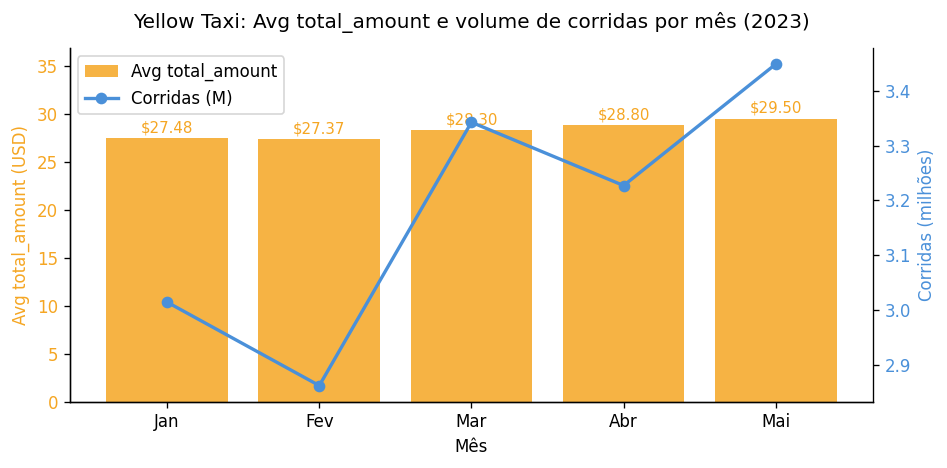

In [0]:
fig, ax1 = plt.subplots(figsize=(8, 4))

color_bar  = "#F5A623"
color_line = "#4A90D9"

bars = ax1.bar(q1["label"], q1["avg_total_amount"], color=color_bar, alpha=0.85, label="Avg total_amount")
ax1.set_ylabel("Avg total_amount (USD)", color=color_bar)
ax1.tick_params(axis="y", labelcolor=color_bar)
ax1.set_ylim(0, q1["avg_total_amount"].max() * 1.25)

for bar, val in zip(bars, q1["avg_total_amount"]):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"${val:.2f}", ha="center", va="bottom", fontsize=9, color=color_bar)

ax2 = ax1.twinx()
ax2.plot(q1["label"], q1["trip_count"] / 1e6, color=color_line, marker="o", linewidth=2, label="Corridas (M)")
ax2.set_ylabel("Corridas (milhões)", color=color_line)
ax2.tick_params(axis="y", labelcolor=color_line)
ax2.spines["right"].set_visible(True)

ax1.set_title("Yellow Taxi: Avg total_amount e volume de corridas por mês (2023)", pad=12)
ax1.set_xlabel("Mês")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

**Leitura:** o ticket médio do Yellow Taxi se mantém relativamente estável ao longo do período. O volume de corridas apresenta variação, que analisamos com mais detalhe na seção de insights.

---
## Query 2: Média de `passenger_count` por hora do dia (Maio, Yellow + Green)

In [0]:
q2 = (
    gold.filter(F.col("pickup_datetime") >= "2023-05-01")
        .filter(F.col("pickup_datetime") <  "2023-06-01")
        .filter(F.col("passenger_count").isNotNull() & (F.col("passenger_count") > 0))
        .groupBy(F.hour("pickup_datetime").alias("hour_of_day"))
        .agg(
            F.round(F.avg("passenger_count"), 2).alias("avg_passenger_count"),
            F.count("*").alias("trip_count"),
        )
        .orderBy("hour_of_day")
        .toPandas()
)

display(q2.rename(columns={
    "hour_of_day": "Hora", "avg_passenger_count": "Avg Passageiros", "trip_count": "Corridas"
}))

Hora,Avg Passageiros,Corridas
0,1.43,89622
1,1.44,58260
2,1.45,37571
3,1.45,24549
4,1.4,16077
5,1.28,18576
6,1.26,46497
7,1.28,94136
8,1.29,128363
9,1.31,144067


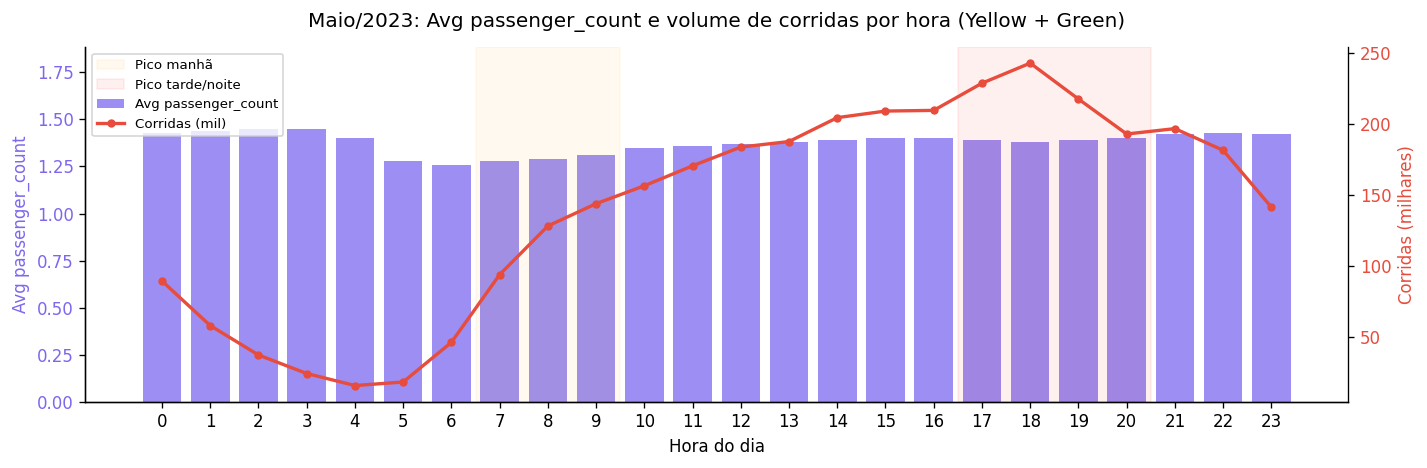

In [0]:
fig, ax1 = plt.subplots(figsize=(12, 4))

color_bar  = "#7B68EE"
color_line = "#E74C3C"

bars = ax1.bar(q2["hour_of_day"], q2["avg_passenger_count"],
               color=color_bar, alpha=0.75, label="Avg passenger_count")
ax1.set_ylabel("Avg passenger_count", color=color_bar)
ax1.tick_params(axis="y", labelcolor=color_bar)
ax1.set_ylim(0, q2["avg_passenger_count"].max() * 1.3)
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(q2["hour_of_day"], q2["trip_count"] / 1000, color=color_line,
         marker="o", markersize=4, linewidth=2, label="Corridas (mil)")
ax2.set_ylabel("Corridas (milhares)", color=color_line)
ax2.tick_params(axis="y", labelcolor=color_line)
ax2.spines["right"].set_visible(True)

ax1.axvspan(6.5, 9.5,  alpha=0.06, color="orange", label="Pico manhã")
ax1.axvspan(16.5, 20.5, alpha=0.06, color="red",    label="Pico tarde/noite")

ax1.set_title("Maio/2023: Avg passenger_count e volume de corridas por hora (Yellow + Green)", pad=12)
ax1.set_xlabel("Hora do dia")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

**Leitura:** a média de passageiros é relativamente constante ao longo do dia (~1.3-1.6), o que reflete o perfil individual das corridas de táxi em NY. O volume de corridas, porém, tem dois picos claros: manhã (7h-9h) e tarde/noite (17h-20h), padrão típico de commute urbano.

---
## Insight 1: Yellow vs Green - volume e ticket médio

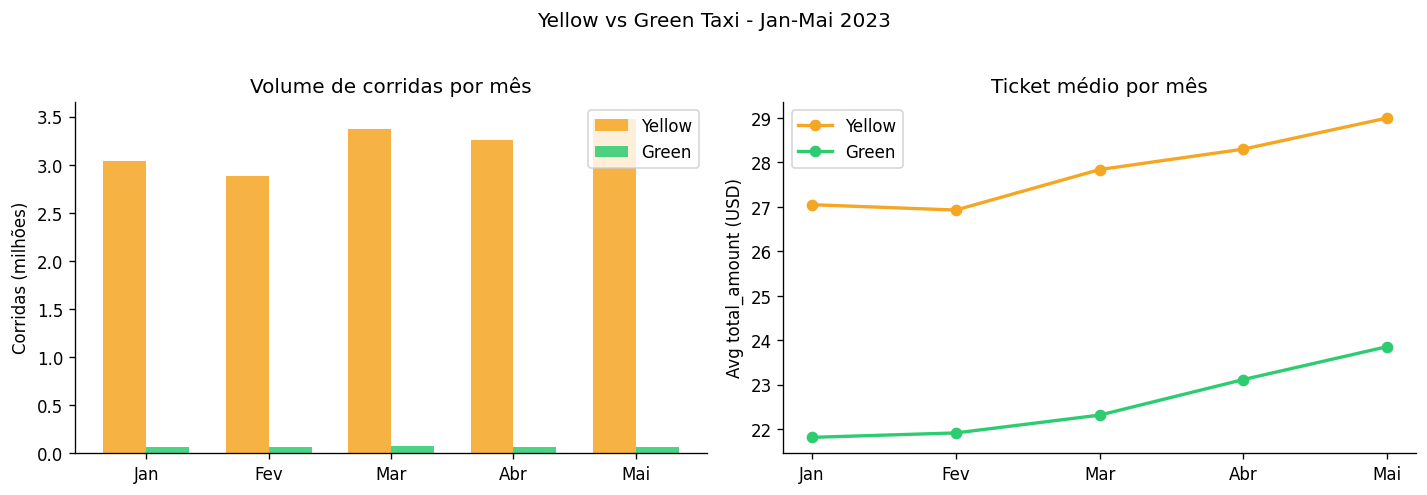


Resumo por tipo:
           Total Corridas  Avg Fare (USD)  Receita Total (USD)
taxi_type                                                     
green              338673           22.61            7657551.0
yellow           16039624           27.82          447006552.0


In [0]:
compare = (
    gold.filter(F.col("pickup_datetime") >= "2023-01-01")
        .filter(F.col("pickup_datetime") <  "2023-06-01")
        .groupBy("taxi_type", F.month("pickup_datetime").alias("month"))
        .agg(
            F.count("*").alias("trips"),
            F.round(F.avg("total_amount"), 2).alias("avg_fare"),
            F.round(F.sum("total_amount"), 0).alias("total_revenue"),
        )
        .orderBy("taxi_type", "month")
        .toPandas()
)

month_labels = {1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai"}
compare["label"] = compare["month"].map(month_labels)

yellow_df = compare[compare["taxi_type"] == "yellow"]
green_df  = compare[compare["taxi_type"] == "green"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Volume
ax = axes[0]
x = range(len(month_labels))
width = 0.35
ax.bar([i - width/2 for i in x], yellow_df["trips"] / 1e6, width, label="Yellow", color="#F5A623", alpha=0.85)
ax.bar([i + width/2 for i in x], green_df["trips"]  / 1e6, width, label="Green",  color="#2ECC71", alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(list(month_labels.values()))
ax.set_ylabel("Corridas (milhões)")
ax.set_title("Volume de corridas por mês")
ax.legend()

# Ticket médio
ax = axes[1]
ax.plot(list(month_labels.values()), yellow_df["avg_fare"], marker="o", color="#F5A623", linewidth=2, label="Yellow")
ax.plot(list(month_labels.values()), green_df["avg_fare"],  marker="o", color="#2ECC71", linewidth=2, label="Green")
ax.set_ylabel("Avg total_amount (USD)")
ax.set_title("Ticket médio por mês")
ax.legend()

plt.suptitle("Yellow vs Green Taxi - Jan-Mai 2023", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print("\nResumo por tipo:")
print(compare.groupby("taxi_type")[["trips", "avg_fare", "total_revenue"]].agg({
    "trips": "sum", "avg_fare": "mean", "total_revenue": "sum"
}).rename(columns={"trips": "Total Corridas", "avg_fare": "Avg Fare (USD)", "total_revenue": "Receita Total (USD)"}).round(2))

**Leitura:** Green Taxi tem volume \~50× menor que Yellow (atende outer boroughs: Bronx, Brooklyn, Queens, Staten Island fora de Manhattan). O ticket médio do Yellow é consistentemente **maior** que o Green (\~$27-29 vs \~$22-24) - Manhattan e aeroportos geram corridas mais caras que os outer boroughs.


---
## Insight 2: Hora de maior receita vs hora de maior demanda

Volume alto não significa receita alta; corridas curtas no horário de pico podem gerar menos receita por corrida do que corridas longas fora do horário de pico.

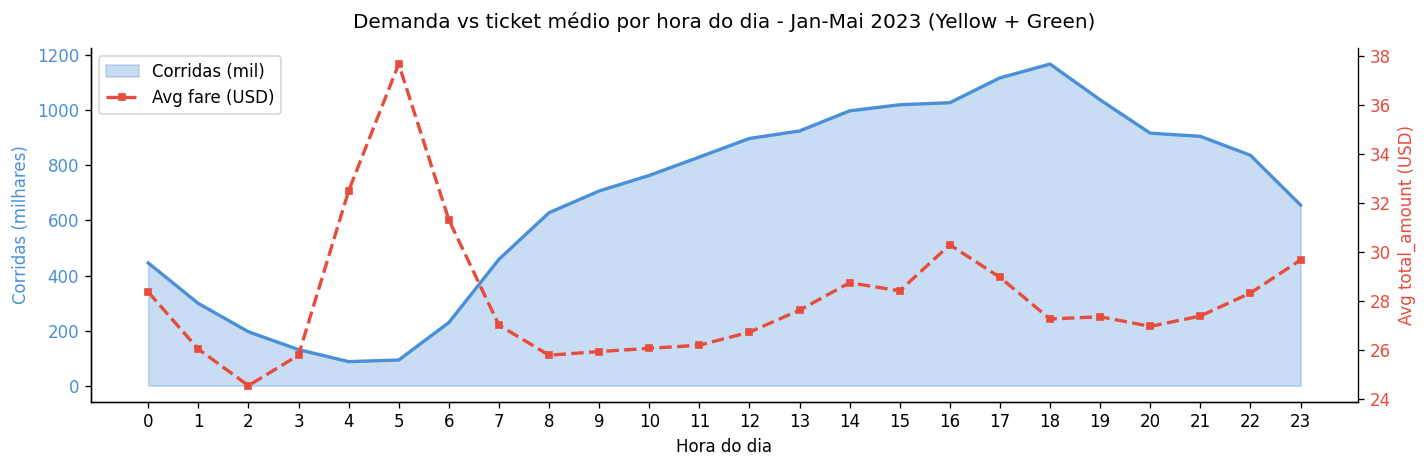

Hora de maior demanda:        18h  (1168k corridas)
Hora de maior ticket médio:   05h  ($37.69)


In [0]:
hourly = (
    gold.filter(F.col("pickup_datetime") >= "2023-01-01")
        .filter(F.col("pickup_datetime") <  "2023-06-01")
        .groupBy(F.hour("pickup_datetime").alias("hour"))
        .agg(
            F.count("*").alias("trips"),
            F.round(F.avg("total_amount"), 2).alias("avg_fare"),
            F.round(F.sum("total_amount") / 1e6, 2).alias("revenue_M"),
        )
        .orderBy("hour")
        .toPandas()
)

fig, ax1 = plt.subplots(figsize=(12, 4))

ax1.fill_between(hourly["hour"], hourly["trips"] / 1000, alpha=0.3, color="#4A90D9", label="Corridas (mil)")
ax1.plot(hourly["hour"], hourly["trips"] / 1000, color="#4A90D9", linewidth=2)
ax1.set_ylabel("Corridas (milhares)", color="#4A90D9")
ax1.tick_params(axis="y", labelcolor="#4A90D9")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(hourly["hour"], hourly["avg_fare"], color="#E74C3C", marker="s",
         markersize=4, linewidth=2, linestyle="--", label="Avg fare (USD)")
ax2.set_ylabel("Avg total_amount (USD)", color="#E74C3C")
ax2.tick_params(axis="y", labelcolor="#E74C3C")
ax2.spines["right"].set_visible(True)

ax1.set_title("Demanda vs ticket médio por hora do dia - Jan-Mai 2023 (Yellow + Green)", pad=12)
ax1.set_xlabel("Hora do dia")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

peak_demand = hourly.loc[hourly["trips"].idxmax()]
peak_fare   = hourly.loc[hourly["avg_fare"].idxmax()]
print(f"Hora de maior demanda:        {int(peak_demand['hour']):02d}h  ({peak_demand['trips']/1000:.0f}k corridas)")
print(f"Hora de maior ticket médio:   {int(peak_fare['hour']):02d}h  (${peak_fare['avg_fare']:.2f})")

**Leitura:** existe uma relação inversa entre demanda e ticket médio. Os horários de pico de corridas (commute da manhã/tarde) têm tickets menores, corridas curtas dentro de Manhattan. As madrugadas (2h-5h) têm ticket médio mais alto, provavelmente corridas para aeroportos (JFK, LaGuardia) e distâncias maiores.

---
## Insight 3: Audit Trail do Pipeline

Quantos registros passaram por cada camada? Quantos foram filtrados e por quê?

In [0]:
from config.settings import PATHS, PIPELINE_START_DATE

bronze_yellow = spark.read.format("delta").load(f"{PATHS['bronze']}/yellow")
bronze_green  = spark.read.format("delta").load(f"{PATHS['bronze']}/green")
silver_yellow = spark.table("nyc_taxi.main.silver_yellow_trips")
silver_green  = spark.table("nyc_taxi.main.silver_green_trips")

counts = {
    "Bronze Yellow":  bronze_yellow.count(),
    "Bronze Green":   bronze_green.count(),
    "Silver Yellow":  silver_yellow.count(),
    "Silver Green":   silver_green.count(),
    "Gold (total)":   gold.count(),
    "Gold Yellow":    gold.filter(F.col("taxi_type") == "yellow").count(),
    "Gold Green":     gold.filter(F.col("taxi_type") == "green").count(),
}

print("=== Registros por camada ===")
for layer, n in counts.items():
    print(f"  {layer:20s}: {n:>10,}")

silver_total = counts["Silver Yellow"] + counts["Silver Green"]
bronze_total = counts["Bronze Yellow"] + counts["Bronze Green"]
gold_total   = counts["Gold (total)"]

print()
print("=== Registros filtrados ===")
silver_dropped = bronze_total - silver_total
gold_dropped   = silver_total - gold_total
print(f"  Bronze → Silver  : {silver_dropped:>8,} removidos  ({100*silver_dropped/bronze_total:.2f}%)  [nulos em pickup_datetime, dropoff_datetime ou total_amount]")
print(f"  Silver → Gold    : {gold_dropped:>8,} removidos  ({100*gold_dropped/silver_total:.2f}%)  [pickup_datetime < {PIPELINE_START_DATE} (datas corrompidas)]")

=== Registros por camada ===
  Bronze Yellow       : 16,186,386
  Bronze Green        :    339,630
  Silver Yellow       : 16,039,728
  Silver Green        :    338,681
  Gold (total)        : 16,378,337
  Gold Yellow         : 16,039,661
  Gold Green          :    338,676

=== Registros filtrados ===
  Bronze → Silver  :  147,607 removidos  (0.89%)  [nulos em pickup_datetime, dropoff_datetime ou total_amount]
  Silver → Gold    :       72 removidos  (0.00%)  [pickup_datetime < 2023-01-01 (datas corrompidas)]


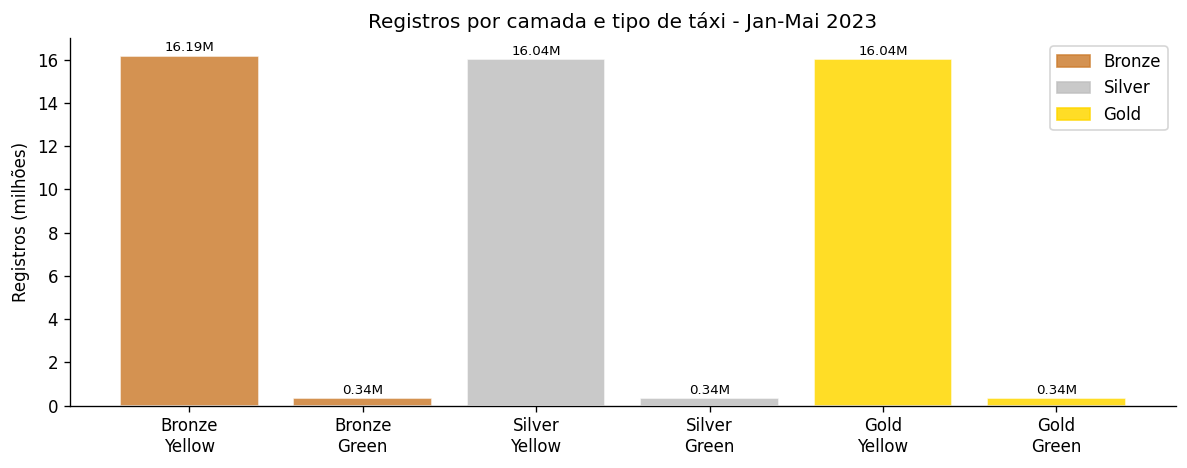

In [0]:
layers = ["Bronze\nYellow", "Bronze\nGreen", "Silver\nYellow", "Silver\nGreen", "Gold\nYellow", "Gold\nGreen"]
values = [
    counts["Bronze Yellow"], counts["Bronze Green"],
    counts["Silver Yellow"], counts["Silver Green"],
    counts["Gold Yellow"],   counts["Gold Green"],
]
colors = ["#CD7F32", "#CD7F32", "#C0C0C0", "#C0C0C0", "#FFD700", "#FFD700"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(layers, [v / 1e6 for v in values], color=colors, alpha=0.85, edgecolor="white")

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{val/1e6:.2f}M", ha="center", va="bottom", fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#CD7F32", alpha=0.85, label="Bronze"),
    Patch(color="#C0C0C0", alpha=0.85, label="Silver"),
    Patch(color="#FFD700", alpha=0.85, label="Gold"),
])

ax.set_ylabel("Registros (milhões)")
ax.set_title("Registros por camada e tipo de táxi - Jan-Mai 2023")
plt.tight_layout()
plt.show()